#**Phase 1 — Load, Explore & Clean**
Python Foundations + Data Cleaning


---


**We will load the data, understand what each column means, and clean up the mess. By the end
of this phase we should have a clean DataFrame with no obvious problems.**

# **Imports**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
RAW_PATH     = 'AmesHousing.csv'
CLEANED_PATH = 'ames_cleaned.csv'

# **Task 1:**

---
# **Load the data using pd.read_csv() and print the first 5 rows**

---

Loading the raw dataset to inspect its structure before making any changes.

In [4]:
df = pd.read_csv(RAW_PATH)
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 2,930   Columns: 82


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# **Task 2:**

---
# **Check the shape**

---

Knowing the number of rows and columns helps us understand the scale of the data
and spot any obvious loading problems.

In [5]:
# Source: Week 2, Day 9 — Data Types & Type Consistency
df.info()
df['MS SubClass'] = df['MS SubClass'].astype(str)
df['Mo Sold'] = df['Mo Sold'].astype('category')
print(df[['MS SubClass', 'Mo Sold']].dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

# **Task 3:**

---
# **Inspect data types: use .info()**

---

Wrong data types cause silent errors — `MS SubClass` looks like a number but is
actually a category code, and `Mo Sold` is a month label not a numeric value.

In [6]:
# Source: Week 2, Day 6 — Quantifying Missingness
def missing_summary(df):
    total = df.isna().sum()
    pct = (df.isna().mean() * 100).round(1)
    return (pd.DataFrame({'missing_count': total, 'missing_percent': pct})
            .sort_values('missing_percent', ascending=False))

print(missing_summary(df))

                missing_count  missing_percent
Pool QC                  2917             99.6
Misc Feature             2824             96.4
Alley                    2732             93.2
Fence                    2358             80.5
Mas Vnr Type             1775             60.6
...                       ...              ...
Mo Sold                     0              0.0
Yr Sold                     0              0.0
Sale Type                   0              0.0
Sale Condition              0              0.0
SalePrice                   0              0.0

[82 rows x 2 columns]


# **Task 4:**

---
# **Find missing values: use .isnull().sum()**

---

**Decision logic:**

| Column group | % Missing | Action | Reason |
|---|---|---|---|
| `Pool QC`, `Misc Feature`, `Alley`, `Fence` | > 80% | Drop column | No useful signal |
| Garage/Bsmt categorical | 3–60% | Fill 'None' | NaN means feature does not exist |
| Garage/Bsmt numeric | ~5% | Fill 0 | NaN means no garage/basement |
| `Lot Frontage` | 17% | Fill median | Numeric and skewed — median is robust |

In [7]:
# Source: Week 2, Day 6 — Dropping Rows vs Dropping Columns
# Source: Week 2, Day 6 — Basic Imputation (Mean, Median, Mode)
def handle_missing(df):
    cols_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence']
    df = df.drop(columns=cols_to_drop)

    cat_none = [ 'Fireplace Qu', 'Mas Vnr Type','Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',  'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure','BsmtFin Type 1', 'BsmtFin Type 2' ]
    for col in cat_none:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    num_zero = ['Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF','Bsmt Full Bath', 'Bsmt Half Bath']
    for col in num_zero:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())
    df = df.dropna()
    return df
df = handle_missing(df)
print(f'Missing after cleaning: {df.isnull().sum().sum()}')
print(f'Shape: {df.shape}')

Missing after cleaning: 0
Shape: (2929, 78)


# **Task 5:**

---
# **Handle duplicates: check with .duplicated().sum() and remove if any**

---

Duplicate rows would inflate the dataset and bias the analysis toward repeated records.

In [8]:
# Source: Week 2, Day 8 — Detecting Duplicates (Full-Row)
def handle_duplicates(df):
    dupes = df.duplicated().sum()
    print(f'Duplicate rows found: {dupes}')
    df = df.drop_duplicates()
    print(f'Shape after deduplication: {df.shape}')
    return df
df = handle_duplicates(df)

Duplicate rows found: 0
Shape after deduplication: (2929, 78)


# **Task 6:**


---


# **Spot outliers: use a boxplot or the IQR method on the target column; cap extreme values at the 99th percentile**

---

We use IQR to detect outliers and cap at the 99th percentile instead of removing rows —
this preserves all 2,929 records while limiting the influence of extreme values.

IQR bounds  — Lower: $3,500  |  Upper: $339,500
Outliers detected: 137 rows
Capped at 99th percentile: $456,690


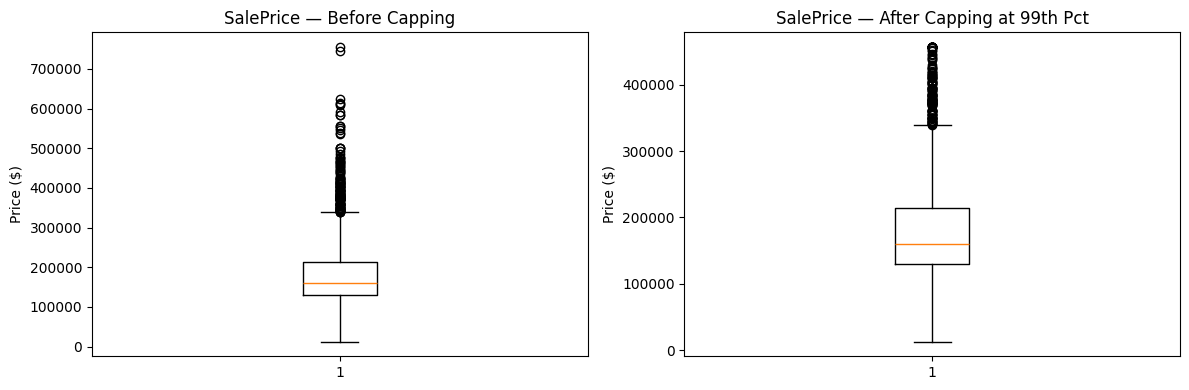

In [9]:
# Source: Week 2, Day 10 — IQR Outlier Detection
# Source: Week 2, Day 11 — Capping (Winsorization) at 99th percentile
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def handle_outliers(df, col='SalePrice'):
    lower, upper = iqr_bounds(df[col])
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'IQR bounds  — Lower: ${lower:,.0f}  |  Upper: ${upper:,.0f}')
    print(f'Outliers detected: {outliers} rows')
    cap_99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap_99)
    print(f'Capped at 99th percentile: ${cap_99:,.0f}')
    return df
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['SalePrice'])
axes[0].set_title('SalePrice — Before Capping')
axes[0].set_ylabel('Price ($)')
df = handle_outliers(df)
axes[1].boxplot(df['SalePrice'])
axes[1].set_title('SalePrice — After Capping at 99th Pct')
axes[1].set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

# **Task 7:**

---
# **Write a clean_data() function that does all the above steps in order so you can reuse it**

---

Packaging all steps into one function makes the pipeline reusable and ensures
the same cleaning logic is applied every time.

In [10]:
# Source: Week 2 Complete — End-to-End Cleaning Sketch
def clean_data(path):
    df = pd.read_csv(path)
    # Step 1
    df['MS SubClass'] = df['MS SubClass'].astype(str)
    df['Mo Sold']     = df['Mo Sold'].astype('category')
    # Step 2
    df = handle_missing(df)
    # Step 3
    df = handle_duplicates(df)
    # Step 4
    df = handle_outliers(df)
    df = df.reset_index(drop=True)
    print(f'clean_data() done — {df.shape[0]:,} rows x {df.shape[1]} columns')
    return df


df_clean = clean_data(RAW_PATH)
df_clean.head()

Duplicate rows found: 0
Shape after deduplication: (2929, 78)
IQR bounds  — Lower: $3,500  |  Upper: $339,500
Outliers detected: 137 rows
Capped at 99th percentile: $456,690
clean_data() done — 2,929 rows x 78 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900.0


# **Task 8:**

---
# **Add 3 checks at the end (e.g., no nulls in key columns, all target values > 0, correct number of columns)**

---

Automated checks catch silent errors that are easy to miss visually —
confirming no nulls, no zero prices, and the correct column count.

In [11]:
# Source: Week 2, Day 6 — Quantifying Missingness
# Source: Week 2, Day 10 — Outlier Handling Validation
def run_checks(df):
    errors = []
    # Check 1
    key_cols = ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Lot Area', 'Year Built']
    for col in key_cols:
        nulls = df[col].isnull().sum()
        if nulls > 0:
            errors.append(f'CHECK 1 FAILED: {col} has {nulls} null values')
    # Check 2
    non_positive = (df['SalePrice'] <= 0).sum()
    if non_positive > 0:
        errors.append(f'CHECK 2 FAILED: {non_positive} rows have SalePrice <= 0')
    # Check 3
    if df.shape[1] != 78:
        errors.append(f'CHECK 3 FAILED: Expected 78 columns, got {df.shape[1]}')
    if errors:
        for e in errors:
            print('FAILED:', e)
    else:
        print('Check 1 PASSED: No nulls in key columns')
        print('Check 2 PASSED: All SalePrice values > 0')
        print('Check 3 PASSED: Column count is 78')
run_checks(df_clean)

Check 1 PASSED: No nulls in key columns
Check 2 PASSED: All SalePrice values > 0
Check 3 PASSED: Column count is 78


## Save Cleaned Data
---

In [12]:
df_clean.to_csv(CLEANED_PATH, index=False)
print(f'Saved to: {CLEANED_PATH}')
print(f'Final shape: {df_clean.shape}')

Saved to: ames_cleaned.csv
Final shape: (2929, 78)
